**Algoritmos Evolucionários**


**Exercício 1 - Ponto 1**


O codigo seguinte aborda as alíneas (a) e (b), onde são criadas funções para gerar um conjunto aleatório de bits, com o tamanho do mesmo escolhido(foi testado conjuntos de 2, 4, 8, 12, 16, 20 bits). Seguidamente, os conjuntos foram testados com pesquisa aleatoria, onde foi possivél perceber que até conjuntos de 20 bits é médio/grande mas o tempo de pesquisa é aceitavel. Para valores de 32 bits ou superior cada pesquisa demora minutos o que torna os testes muito demorados (30 testes por conjunto em estudo). 

Alínea 1b


C:\Users\André\AppData\Local\Temp\ipykernel_3496\2802316067.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(resultados_tentativas, labels=tamanhos_testados, patch_artist=True)
C:\Users\André\AppData\Local\Temp\ipykernel_3496\2802316067.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(resultados_tempos, labels=tamanhos_testados, patch_artist=True)


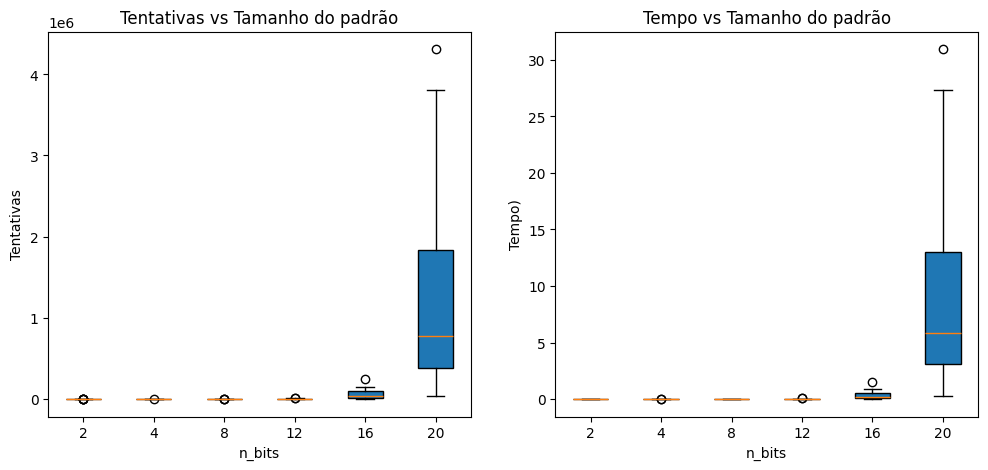

2 bits: 4 tentativas médias	 0.00000000 segundos
4 bits: 16 tentativas médias	 0.00008291 segundos
8 bits: 201 tentativas médias	 0.00072967 segundos
12 bits: 3518 tentativas médias	 0.01557476 segundos
16 bits: 62897 tentativas médias	 0.36071995 segundos
20 bits: 1176489 tentativas médias	 8.60406597 segundos


In [11]:
import random
import time
import numpy as np
import matplotlib.pyplot as plt


def gerar_padrao_aleatorio(n_bits: int, seed=None):
    if seed is not None:
        random.seed(seed)
    return [random.randint(0, 1) for _ in range(n_bits)]

def pesquisa_aleatoria(n_bits, n_repeticoes=30,tempo_limite=3600):
    tempos, tentativas = [], []
    for r in range(n_repeticoes):
        alvo = gerar_padrao_aleatorio(n_bits, seed=r)
        inicio = time.time()
        count = 0
        while True:
            guess = gerar_padrao_aleatorio(n_bits)
            count += 1
            if guess == alvo:
                break

            if time.time() - inicio > tempo_limite:
                print("\nTempo limite de 1 hora atingido")
                tempo_decorrido = time.time() - inicio
                tempos.append(tempo_decorrido)
                tentativas.append(count)
                return tentativas, tempos
        tempo_decorrido = time.time() - inicio
        tempos.append(tempo_decorrido)
        tentativas.append(count)
        
    return tentativas, tempos


def experimento_pesquisa_aleatoria(tamanhos):
    resultados_tentativas = []
    resultados_tempos = []

    for n in tamanhos:
        tent, t = pesquisa_aleatoria(n, 30, 3600)
        resultados_tentativas.append(tent)
        resultados_tempos.append(t)

    tamanhos_testados = tamanhos[:len(resultados_tentativas)]

    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.boxplot(resultados_tentativas, labels=tamanhos_testados, patch_artist=True)
    plt.title("Tentativas vs Tamanho do padrão")
    plt.xlabel("n_bits")
    plt.ylabel("Tentativas")

    plt.subplot(1,2,2)
    plt.boxplot(resultados_tempos, labels=tamanhos_testados, patch_artist=True)
    plt.title("Tempo vs Tamanho do padrão")
    plt.xlabel("n_bits")
    plt.ylabel("Tempo)")
    plt.show()
    
    return resultados_tentativas, resultados_tempos


if __name__ == "__main__":
    print("Alínea 1b")
    tamanhos = [2, 4, 8, 12, 16, 20]
    resultados_tent, resultados_temp = experimento_pesquisa_aleatoria(tamanhos)

    for i, n in enumerate(tamanhos):
        print(f"{n} bits: {np.mean(resultados_tent[i]):.0f} tentativas médias\t {np.mean(resultados_temp[i]):.8f} segundos")

O codigo seguinte aborda as alíneas (c) e (d), com a criação da função que calcula o valor de fitness de uma amostra, uma função que inverte um bit aleatório de um conjunto em estudo e por fim uma função do genero hill climbing, onde se gera uma solução aleatória que não é igual ao alvo, e esta é alterada(leva mutação) com o intuito de melhorar o valor do fitness. Este processo acaba quando se encontra o alvo, ou seja, chega-se a um fitness=1 ou quando acontece mais de 1000 iterações e não se chegou a um valor de fitness=1. É ainda importante referir que para conjuntos acima de 135 bits já não há convergência de 30/30 no 30 testes efetuados por conjunto. 

In [ ]:
def fitness(padrao, alvo):
    return np.sum(np.array(padrao) == np.array(alvo)) / len(alvo)

def mutar(padrao):
    novo = padrao.copy()
    i = random.randrange(len(novo))
    novo[i] = 1 - novo[i]
    return novo

def busca_local_por_mutacao(alvo, max_iter=1000):
    atual = gerar_padrao_aleatorio(len(alvo))
    melhor_fit = fitness(atual, alvo)
    for i in range(max_iter):
        candidato = mutar(atual)
        f = fitness(candidato, alvo)
        if f > melhor_fit:
            atual, melhor_fit = candidato, f
        if melhor_fit == 1.0:
            return True, i + 1  
    return False, max_iter  


def testar_convergencia_busca_local(n_bits=8, n_testes=30):
    resultados = []
    tempos = []
    for r in range(n_testes):
        alvo = gerar_padrao_aleatorio(n_bits, seed=r)
        inicio = time.time()
        convergiu, iteracoes = busca_local_por_mutacao(alvo)
        tempo_decorrido = time.time() - inicio
        resultados.append((convergiu, iteracoes))
        tempos.append(tempo_decorrido)
    n_convergiu = sum(c for c, _ in resultados)
    print(f"\nConvergiu: {n_convergiu}/{n_testes} ({n_convergiu/n_testes*100:.1f}%)")
    print(f"Média de iterações: {np.mean([it for _, it in resultados]):.1f}")
    print(f"Média de tempo: {np.mean(tempos):.6f}s")
    return resultados, tempos

if __name__ == "__main__":
    print("Alínea 1d")
    testar_convergencia_busca_local(n_bits=135, n_testes=30)


Alínea 1d

 Convergiu: 29/30 (96.7%)
Média de iterações: 594.3
Média de tempo: 0.010449s


No codigo seguinte procedemos com execução da alínea 2 da pergunta 1, onde é implementado um algoritmo evolutivo básico para encontrar um padrão bínario igual ao alvo. Assim, começamos por gerar uma população de 100 padrões e avaliamos o fitness de cada um. Posteriormente, os 30 melhores padrões são mantido e usados para gerar filhos por mutação, criando assim uma nova população. É importante dizer que o processo repete-se até a evolução estagnar(ou seja, se não melhorar o fitness nas ultimas 50 gerações).


 Alínea 2
Convergiu na geração 107
Convergiu na geração 103
Convergiu na geração 105
Convergiu na geração 107
Convergiu na geração 116
Convergiu na geração 113
Convergiu na geração 99
Convergiu na geração 101
Convergiu na geração 104
Convergiu na geração 115
Convergiu na geração 103
Convergiu na geração 103
Convergiu na geração 112
Convergiu na geração 105
Convergiu na geração 110
Convergiu na geração 120
Convergiu na geração 101
Convergiu na geração 116
Convergiu na geração 116
Convergiu na geração 99
Convergiu na geração 99
Convergiu na geração 110
Convergiu na geração 127
Convergiu na geração 107
Convergiu na geração 120
Convergiu na geração 112
Convergiu na geração 122
Convergiu na geração 105
Convergiu na geração 127
Convergiu na geração 108


C:\Users\André\AppData\Local\Temp\ipykernel_3496\1653932588.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(resultados_fit, labels=['Evolutivo'], patch_artist=True)
C:\Users\André\AppData\Local\Temp\ipykernel_3496\1653932588.py:57: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(tempos, labels=['Evolutivo'], patch_artist=True)


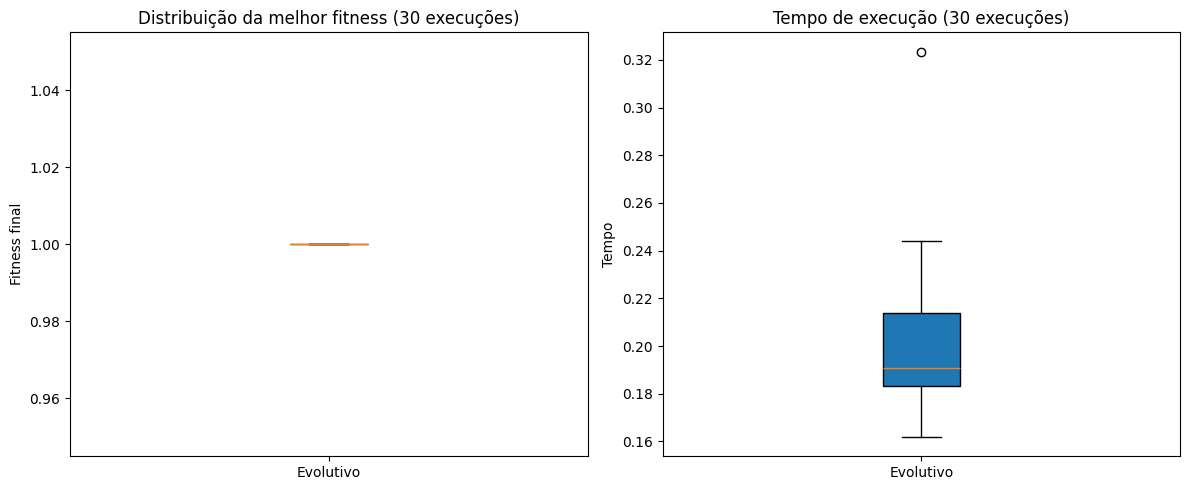

 Média fitness: 1.000 ± 0.000
 Média tempo: 0.201s


In [ ]:
def evolutivo_basico(alvo, tam_pop=100, elite=0.3, max_gen=1000):
    n_elite = int(tam_pop * elite)
    estagnou_maximo = 20
    estagnou = 0
    best_fit = -1.0
    pop = [gerar_padrao_aleatorio(len(alvo)) for _ in range(tam_pop)]
    best_fits = []

    for gen in range(max_gen):
        fits = [fitness(ind, alvo) for ind in pop]
        best = max(fits)
        best_fits.append(best)

        if best > best_fit:
            best_fit = best
            estagnou = 0
        else:
            estagnou += 1

        if best == 1.0 or estagnou == estagnou_maximo:
            return best_fits[-1], best_fits
        
        indices = np.argsort(fits)[::-1]
        elite_pop = [pop[i] for i in indices[:n_elite]]

        novos = elite_pop.copy()
        while len(novos) < tam_pop:
            pai = random.choice(elite_pop)
            filho = mutar(pai)
            novos.append(filho)
        pop = novos

    return best_fits[-1], best_fits

def experimento_evolutivo(n_bits=8, n_repeticoes=30):
    resultados_fit = []
    resultados_ger = []
    tempos = []

    for r in range(n_repeticoes):
        alvo = gerar_padrao_aleatorio(n_bits, seed=r)
        inicio = time.time()
        fit_final, n_gen = evolutivo_basico(alvo)
        tempos.append(time.time() - inicio)
        resultados_fit.append(fit_final)
        resultados_ger.append(n_gen)

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.boxplot(resultados_fit, labels=['Evolutivo'], patch_artist=True)
    plt.title("Distribuição da melhor fitness (30 execuções)")
    plt.ylabel("Fitness final")

    plt.subplot(1,2,2)
    plt.boxplot(tempos, labels=['Evolutivo'], patch_artist=True)
    plt.title("Tempo de execução (30 execuções)")
    plt.ylabel("Tempo")

    plt.tight_layout()
    plt.show()

    print(f" Média fitness: {np.mean(resultados_fit):.3f} ± {np.std(resultados_fit):.3f}")
    print(f" Média tempo: {np.mean(tempos):.3f}s")
    return resultados_fit, tempos


if __name__ == "__main__":
    print("\n Alínea 2")
    experimento_evolutivo(n_bits=135, n_repeticoes=30)


No codigo seguinte procedemos com execução da alínea 3 da pergunta 1, onde é implementado um algoritmo evolutivo com cruzamento para encontrar um padrão bínario igual ao alvo. Assim, começamos por gerar uma população de 100 padrões e avaliamos o fitness de cada um. Posteriormente, os 30 melhores padrões são mantido e usados para gerar filhos por cruzamento entre pais (isto com o uso da função de cruzamento criada com o intuito de miturar dois conjuntos diferentes). Depois disso existe a chance do filho criado sofrer mutação, sendo acrescentado de seguida (mesmo não levando mutação) á nova população. O procedimento de adicionar novos filhos repete-se até ser formada novamente uma população de 100 padrões.

Convergiu na geração 18
Convergiu na geração 9
Teste  1: SemCruz=1.000(0.016s), ComCruz=1.000(0.011s), HillClimb=1.000(0.000s)
Convergiu na geração 14
Convergiu na geração 13
Teste  2: SemCruz=1.000(0.008s), ComCruz=1.000(0.016s), HillClimb=1.000(0.000s)
Convergiu na geração 16
Convergiu na geração 9
Teste  3: SemCruz=1.000(0.014s), ComCruz=1.000(0.003s), HillClimb=1.000(0.008s)
Convergiu na geração 19
Convergiu na geração 8
Teste  4: SemCruz=1.000(0.013s), ComCruz=1.000(0.008s), HillClimb=1.000(0.000s)
Convergiu na geração 18
Convergiu na geração 8
Teste  5: SemCruz=1.000(0.014s), ComCruz=1.000(0.007s), HillClimb=1.000(0.000s)
Convergiu na geração 20
Convergiu na geração 11
Teste  6: SemCruz=1.000(0.021s), ComCruz=1.000(0.010s), HillClimb=1.000(0.001s)
Convergiu na geração 15
Convergiu na geração 12
Teste  7: SemCruz=1.000(0.010s), ComCruz=1.000(0.010s), HillClimb=1.000(0.000s)
Convergiu na geração 21
Convergiu na geração 9
Teste  8: SemCruz=1.000(0.018s), ComCruz=1.000(0.011s), HillC

C:\Users\André\AppData\Local\Temp\ipykernel_3496\2551820062.py:97: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxes = plt.boxplot([resultados_sem_cruz, resultados_com_cruz, resultados_hillclimb],
C:\Users\André\AppData\Local\Temp\ipykernel_3496\2551820062.py:104: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxes = plt.boxplot([tempos_sem_cruz, tempos_com_cruz, tempos_hillclimb],
C:\Users\André\AppData\Local\Temp\ipykernel_3496\2551820062.py:113: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxes = plt.boxplot([gens_sem, gens_com, iteracoes_hillclimb],


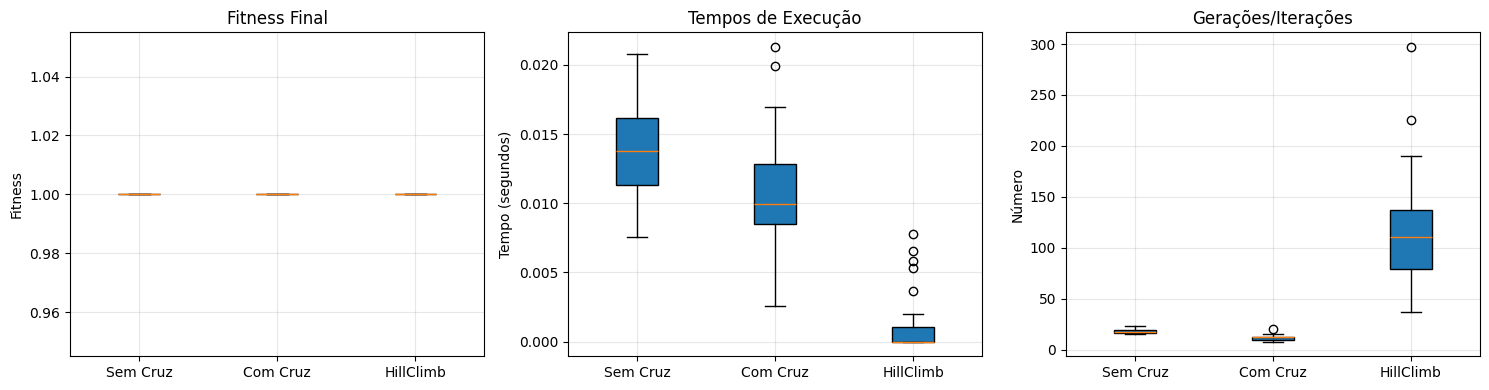


Comparações
Sem Cruzamento:  Fitness=1.000, Tempo=0.014s, Gerações=17.9
Com Cruzamento:  Fitness=1.000, Tempo=0.011s, Gerações=11.7
HillClimb:       Fitness=1.000, Tempo=0.001s, Iterações=118.4


In [10]:
def cruzamento(p1, p2):
    n = len(p1)
    ponto = random.randint(1, n-1)
    filho = p1[:ponto] + p2[ponto:]
    return filho


def evolutivo_com_cruzamento(alvo, tam_pop=100, elite=0.3, max_gen=1000, prob_mut=0.1):
    n_elite = int(tam_pop * elite)
    estagnou_maximo = 20
    estagnou = 0
    best_fit = -1.0
    pop = [gerar_padrao_aleatorio(len(alvo)) for _ in range(tam_pop)]
    best_fits = []

    for gen in range(max_gen):
        fits = [fitness(ind, alvo) for ind in pop]
        best = max(fits)
        best_fits.append(best)

        if best > best_fit:
            best_fit = best
            estagnou = 0
        else:
            estagnou += 1

        if best == 1.0 or estagnou == estagnou_maximo:
            print(f"Convergiu na geração {gen}")
            return best_fits[-1], best_fits

        indices = np.argsort(fits)[::-1]
        elite_pop = [pop[i] for i in indices[:n_elite]]

        novos = elite_pop.copy()
        while len(novos) < tam_pop:
            p1, p2 = random.sample(elite_pop, 2)
            filho = cruzamento(p1, p2)  
            
            if random.random() < prob_mut:
                filho = mutar(filho)
            
            novos.append(filho)
        pop = novos

    return best_fits[-1], best_fits


def comparar_algoritmos(n_bits=8, n_repeticoes=30):
    
    resultados_sem_cruz = []
    resultados_com_cruz = []
    resultados_hillclimb = []
    historicos_sem = []
    historicos_com = []
    tempos_sem_cruz = []
    tempos_com_cruz = []
    tempos_hillclimb = []
    iteracoes_hillclimb = []
    
    for r in range(n_repeticoes):
        alvo = gerar_padrao_aleatorio(n_bits, seed=r)
        
        inicio = time.time()
        fit_final_sem, hist_sem = evolutivo_basico(alvo)
        tempo_sem = time.time() - inicio
        resultados_sem_cruz.append(fit_final_sem)
        historicos_sem.append(hist_sem)
        tempos_sem_cruz.append(tempo_sem)
        
        inicio = time.time()
        fit_final_com, hist_com = evolutivo_com_cruzamento(alvo)
        tempo_com = time.time() - inicio
        resultados_com_cruz.append(fit_final_com)
        historicos_com.append(hist_com)
        tempos_com_cruz.append(tempo_com)
        
        inicio = time.time()
        convergiu, iteracoes = busca_local_por_mutacao(alvo)
        tempo_hill = time.time() - inicio
        
        if convergiu:
            fit_hill = 1.0
        else:
            padrao_final = gerar_padrao_aleatorio(n_bits)
            fit_hill = fitness(padrao_final, alvo)
        
        resultados_hillclimb.append(fit_hill)
        tempos_hillclimb.append(tempo_hill)
        iteracoes_hillclimb.append(iteracoes)
        
        print(f"Teste {r+1:2d}: SemCruz={fit_final_sem:.3f}({tempo_sem:.3f}s), ComCruz={fit_final_com:.3f}({tempo_com:.3f}s), HillClimb={fit_hill:.3f}({tempo_hill:.3f}s)")

    
    plt.figure(figsize=(15, 4))
    
    plt.subplot(1, 3, 1)
    boxes = plt.boxplot([resultados_sem_cruz, resultados_com_cruz, resultados_hillclimb], 
                labels=['Sem Cruz', 'Com Cruz', 'HillClimb'], patch_artist=True)
    plt.title("Fitness Final")
    plt.ylabel("Fitness")
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 3, 2)
    boxes = plt.boxplot([tempos_sem_cruz, tempos_com_cruz, tempos_hillclimb], 
                labels=['Sem Cruz', 'Com Cruz', 'HillClimb'], patch_artist=True)
    plt.title("Tempos de Execução")
    plt.ylabel("Tempo (segundos)")
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 3, 3)
    gens_sem = [len(h) for h in historicos_sem]
    gens_com = [len(h) for h in historicos_com]
    boxes = plt.boxplot([gens_sem, gens_com, iteracoes_hillclimb], 
                labels=['Sem Cruz', 'Com Cruz', 'HillClimb'], patch_artist=True)
    plt.title("Gerações/Iterações")
    plt.ylabel("Número")
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nComparações")
    print(f"Sem Cruzamento:  Fitness={np.mean(resultados_sem_cruz):.3f}, Tempo={np.mean(tempos_sem_cruz):.3f}s, Gerações={np.mean([len(h) for h in historicos_sem]):.1f}")
    print(f"Com Cruzamento:  Fitness={np.mean(resultados_com_cruz):.3f}, Tempo={np.mean(tempos_com_cruz):.3f}s, Gerações={np.mean([len(h) for h in historicos_com]):.1f}")
    print(f"HillClimb:       Fitness={np.mean(resultados_hillclimb):.3f}, Tempo={np.mean(tempos_hillclimb):.3f}s, Iterações={np.mean(iteracoes_hillclimb):.1f}")

if __name__ == "__main__":
    comparar_algoritmos(n_bits=32, n_repeticoes=30)

Os três métodos testados, sendo estes o hill-climbing, algoritmo evolutivo com mutação e algoritmo evolutivo com cruzamento, apresentam comportamentos distintos. O hill-climbing é rápido e simples, mas tende a ficar preso em máximos locais, sendo mais eficaz em padrões pequenos, com baixo número de bits(para conjuntos com mais de 135 bits começa a não convergir ou seja não chega a fitness=1). O evolutivo com mutação garante maior diversidade e, portanto, consegue escapar de máximos locais, mas requer mais gerações e tempo de execução. Já o evolutivo com cruzamento combina a exploração da mutação com a recombinação de boas soluções, apresentando geralmente melhores resultados em termos de fitness final e convergência mais rápida do que a versão apenas com mutação. Em termos de tempo de execução, hill-climbing é o mais eficiente, seguido de valores muito proximos no evolutivo com cruzamento e o evolutivo com mutação pura.